In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization, Activation, Add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import mnist, cifar10
from google.colab import files
from sklearn.metrics import mean_squared_error
import time
import os

%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

Saving Pomegranates.png to Pomegranates.png
✅ Image loaded. Shape: (256, 256)
   Min pixel value: 0.000
   Max pixel value: 0.990


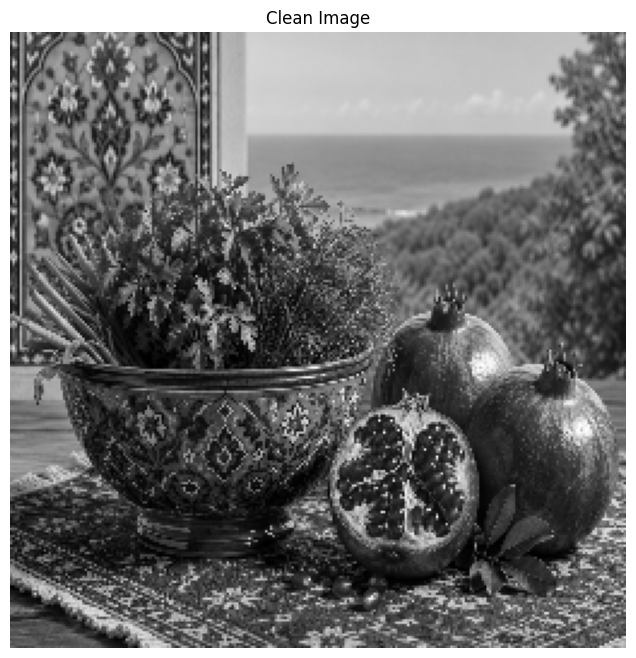

In [3]:
# Upload an image
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

# Load and convert to grayscale (for simplicity in this opening)
image = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Normalize to [0, 1] range
image_clean = image_gray.astype('float32') / 255.0

# Resize for faster processing (optional)
image_clean = cv2.resize(image_clean, (256, 256))

print(f"✅ Image loaded. Shape: {image_clean.shape}")
print(f"   Min pixel value: {image_clean.min():.3f}")
print(f"   Max pixel value: {image_clean.max():.3f}")

# Display the clean image
plt.figure(figsize=(8, 8))
plt.imshow(image_clean, cmap='gray')
plt.title('Clean Image')
plt.axis('off')
plt.show()

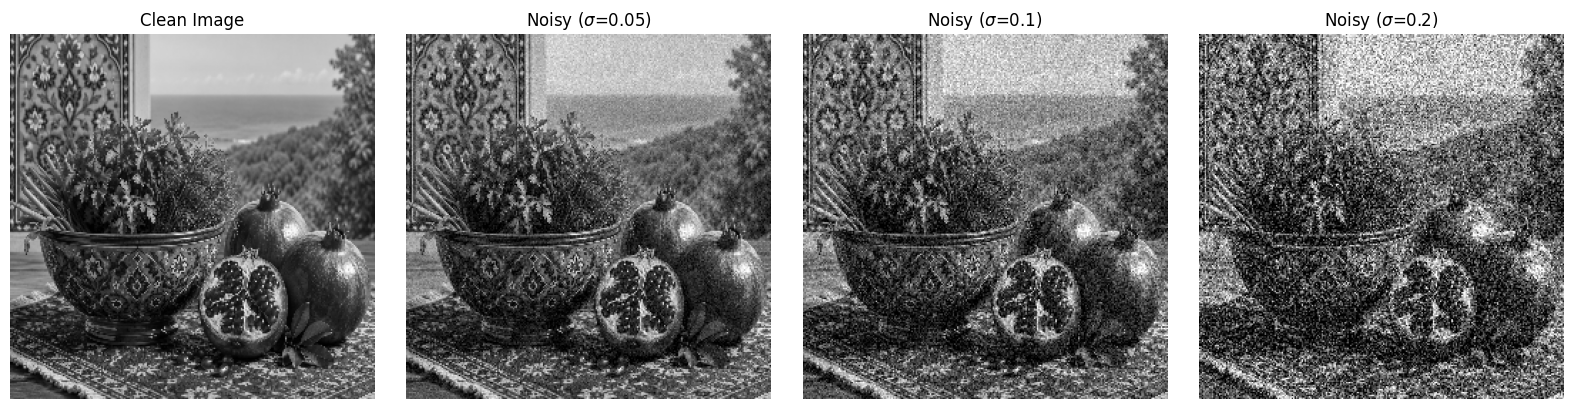

✅ Using noise with σ=0.1 for the remainder of this section


In [4]:
def add_gaussian_noise(image, sigma=0.1):
    """Add Gaussian noise to an image."""
    noise = np.random.normal(0, sigma, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 1)

# Add noise with different intensities
sigma_values = [0.05, 0.1, 0.2]
noisy_images = {}

for sigma in sigma_values:
    noisy_images[sigma] = add_gaussian_noise(image_clean, sigma)

# Display the results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image_clean, cmap='gray')
axes[0].set_title('Clean Image')
axes[0].axis('off')

for i, sigma in enumerate(sigma_values):
    axes[i+1].imshow(noisy_images[sigma], cmap='gray')
    # Fixed: Use double backslash for LaTeX sigma
    axes[i+1].set_title(f'Noisy ($\\sigma$={sigma})')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# Use sigma=0.1 for the rest of the hands-on opening
image_noisy = noisy_images[0.1]
print(f"✅ Using noise with σ=0.1 for the remainder of this section")

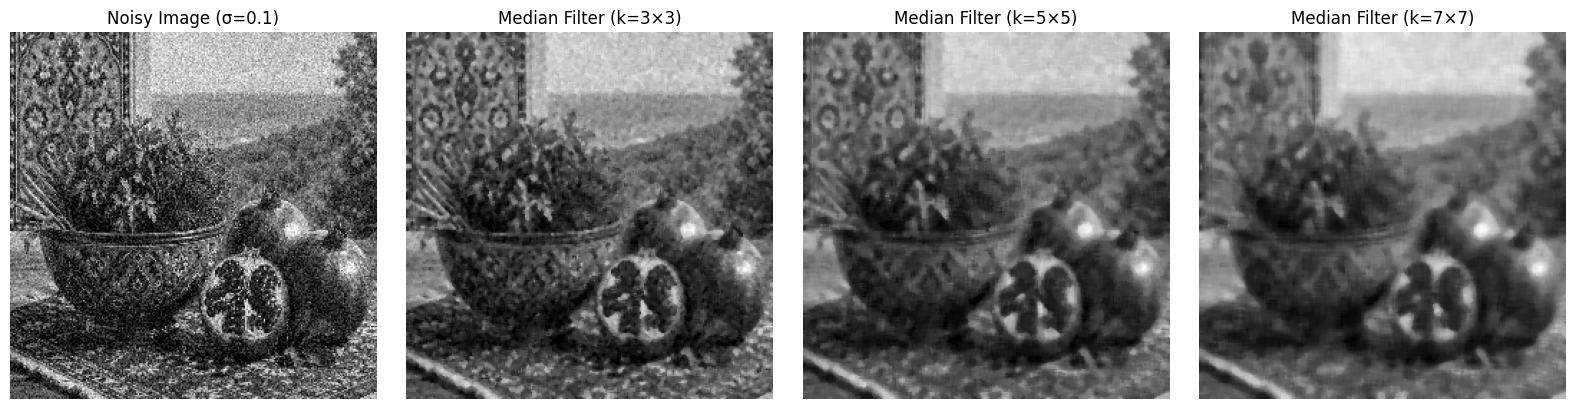

PSNR (Median filter, k=3): 20.22 dB


In [5]:
# Apply median filter with different kernel sizes
kernel_sizes = [3, 5, 7]
denoised_median = {}

for k in kernel_sizes:
    denoised_median[k] = cv2.medianBlur((image_noisy * 255).astype(np.uint8), k) / 255.0

# Display the results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image_noisy, cmap='gray')
axes[0].set_title('Noisy Image (σ=0.1)')
axes[0].axis('off')

for i, k in enumerate(kernel_sizes):
    axes[i+1].imshow(denoised_median[k], cmap='gray')
    axes[i+1].set_title(f'Median Filter (k={k}×{k})')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# Compute PSNR for the best median filter result (k=3)
# Specify data_range=1.0 to avoid dtype mismatch warning
from skimage.metrics import peak_signal_noise_ratio
psnr_median = peak_signal_noise_ratio(image_clean, denoised_median[3], data_range=1.0)
print(f"PSNR (Median filter, k=3): {psnr_median:.2f} dB")

In [6]:
def build_cnn_denoiser(input_shape=(256, 256, 1)):
    """Build a simple CNN for image denoising."""
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    outputs = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

# Build the model
cnn_denoiser = build_cnn_denoiser()
cnn_denoiser.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,001 (437.50 KB)

 Trainable params: 112,001 (437.50 KB)

 Non-trainable params: 0 (0.00 B)

✅ Training data created:
   X_train shape: (2000, 32, 32, 1)
   y_train shape: (2000, 32, 32, 1)


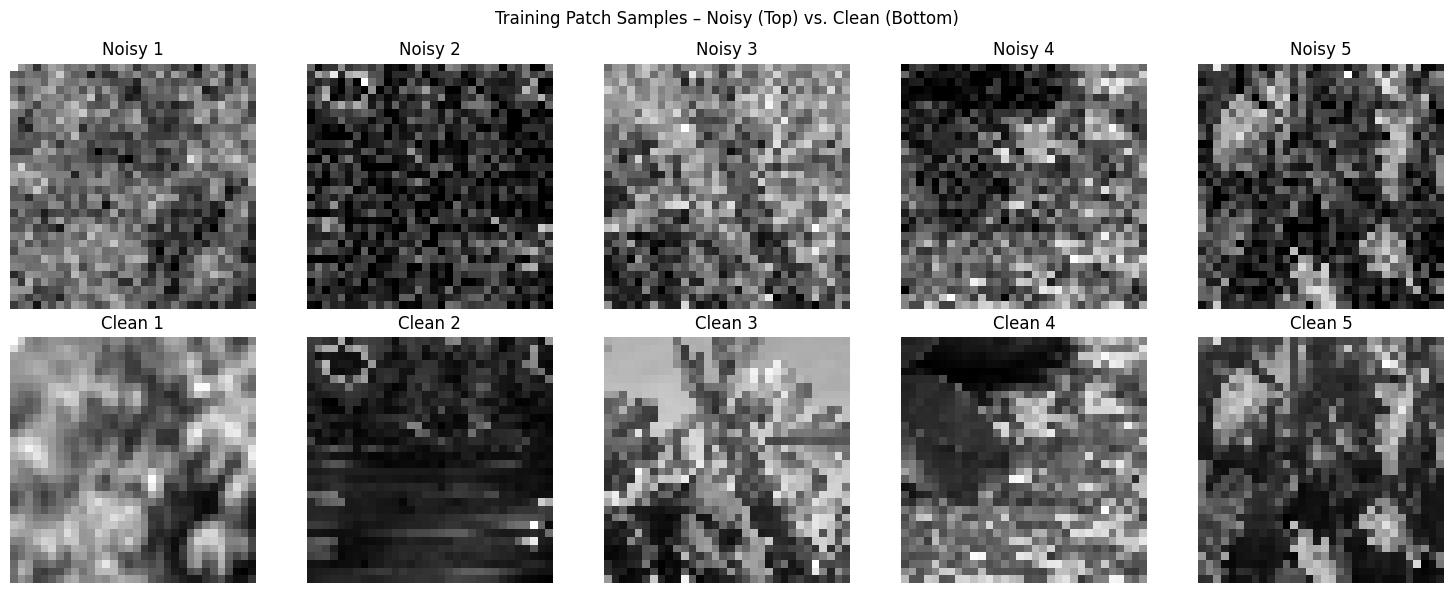

In [8]:
# Generate training data from the single image
def create_training_data(image, num_samples=1000, patch_size=32, sigma=0.1):
    """Create noisy-clean patch pairs from a single image."""
    h, w = image.shape
    clean_patches = []
    noisy_patches = []

    for _ in range(num_samples):
        # Random crop
        i = np.random.randint(0, h - patch_size)
        j = np.random.randint(0, w - patch_size)
        patch = image[i:i+patch_size, j:j+patch_size]

        # Add noise
        noise = np.random.normal(0, sigma, patch.shape)
        noisy_patch = patch + noise
        noisy_patch = np.clip(noisy_patch, 0, 1)

        clean_patches.append(patch)
        noisy_patches.append(noisy_patch)

    return np.array(noisy_patches).reshape(-1, patch_size, patch_size, 1), \
           np.array(clean_patches).reshape(-1, patch_size, patch_size, 1)

# Generate training data
patch_size = 32
X_train, y_train = create_training_data(image_clean, num_samples=2000, patch_size=patch_size)

print(f"✅ Training data created:")
print(f"   X_train shape: {X_train.shape}")
print(f"   y_train shape: {y_train.shape}")

# Display sample patches
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    # Noisy patches (top row)
    axes[0, i].imshow(X_train[i, :, :, 0], cmap='gray')
    axes[0, i].set_title(f'Noisy {i+1}')
    axes[0, i].axis('off')

    # Clean patches (bottom row)
    axes[1, i].imshow(y_train[i, :, :, 0], cmap='gray')
    axes[1, i].set_title(f'Clean {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Training Patch Samples – Noisy (Top) vs. Clean (Bottom)')
plt.tight_layout()
plt.show()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,001 (437.50 KB)

 Trainable params: 112,001 (437.50 KB)

 Non-trainable params: 0 (0.00 B)

✅ X_train shape: (2000, 32, 32, 1)
✅ y_train shape: (2000, 32, 32, 1)

🔄 Training CNN denoiser...
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0227 - mae: 0.1113 - val_loss: 0.0078 - val_mae: 0.0651 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0063 - mae: 0.0598 - val_loss: 0.0050 - val_mae: 0.0543 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0054 - mae: 0.0561 - val_loss: 0.0047 - val_mae: 0.0525 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0046 - mae: 0.0516 - val_loss: 0.0045 - val_mae: 0.0516 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0044 - mae: 0.0506 - val_loss: 0.0043 - val_mae: 0.0499 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0042 - mae: 0.0492 - val_loss: 0.0041 - val_mae: 0.0488 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 

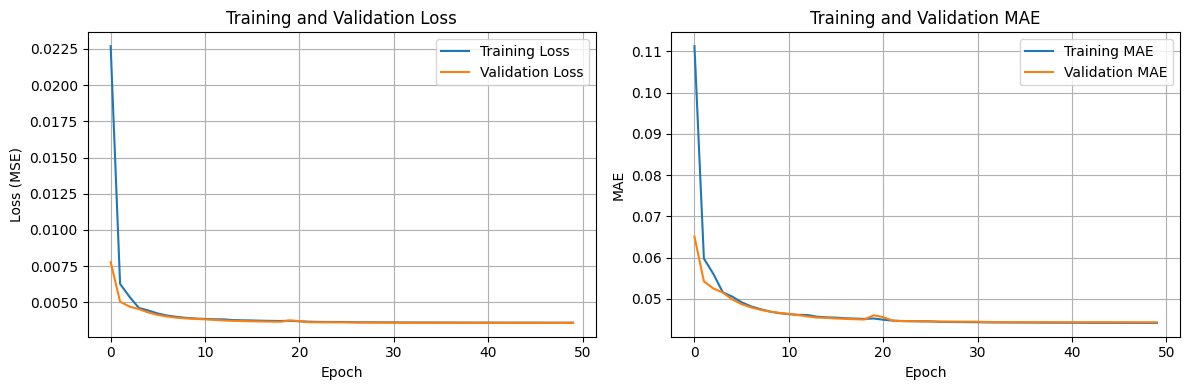

In [9]:
# Define patch size (must match the patch size used in create_training_data)
patch_size = 32

# Build the CNN denoiser
def build_cnn_denoiser(input_shape=(patch_size, patch_size, 1)):
    """Build a simple CNN for image denoising."""
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    outputs = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

# Build the model
cnn_denoiser = build_cnn_denoiser(input_shape=(patch_size, patch_size, 1))
cnn_denoiser.summary()

print(f"✅ X_train shape: {X_train.shape}")
print(f"✅ y_train shape: {y_train.shape}")

# Train the CNN denoiser
print("\n🔄 Training CNN denoiser...")
start_time = time.time()

history = cnn_denoiser.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]
)

training_time = time.time() - start_time
print(f"✅ Training completed in {training_time:.2f} seconds")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

🔄 Denoising image using patch-based CNN...
✅ CNN denoising complete!

📊 DENOISING RESULTS COMPARISON
Method          PSNR (dB)    SSIM
----------------------------------------
Noisy Image     20.30        0.6376
Median Filter   20.22        0.5838
CNN Denoiser    24.46        0.8242


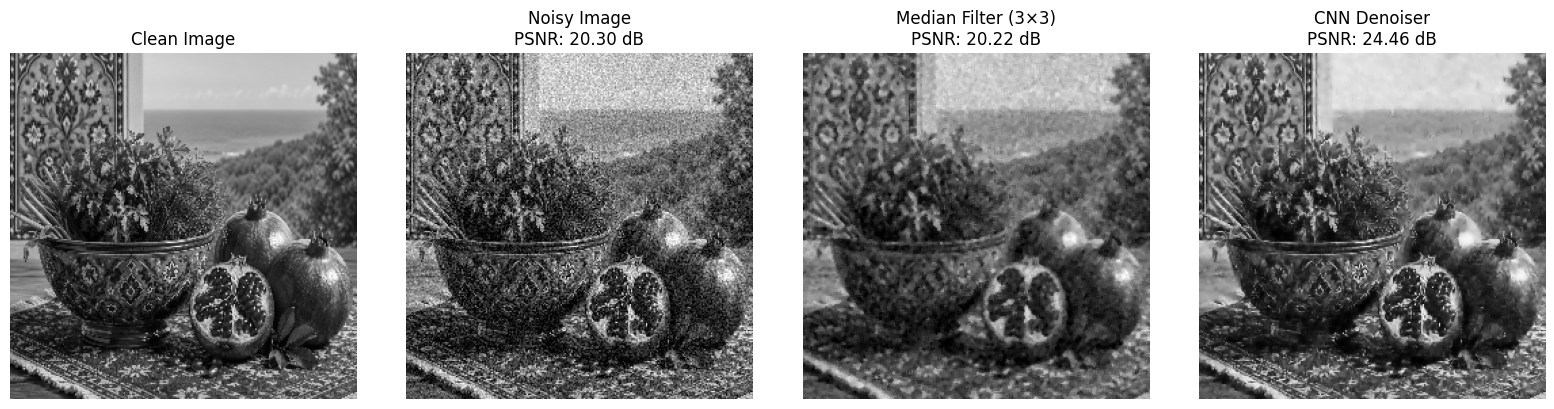

In [11]:
# ============================================
#      Patch-based prediction
# ============================================

def denoise_image_patches(model, image, patch_size=32, stride=16):
    """
    Denoise an image by processing it in patches.
    Uses overlapping patches and averages the results for smooth reconstruction.

    Args:
        model: Trained CNN denoiser
        image: Input noisy image (H, W)
        patch_size: Size of patches (default: 32)
        stride: Stride between patches (default: 16 for overlap)

    Returns:
        Denoised image (H, W)
    """
    h, w = image.shape
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size

    # Pad the image to be divisible by patch_size
    padded = np.pad(image, ((0, pad_h), (0, pad_w)), mode='reflect')
    padded_h, padded_w = padded.shape

    # Initialize output arrays
    output = np.zeros((padded_h, padded_w))
    weights = np.zeros((padded_h, padded_w))

    # Process patches with overlap
    for i in range(0, padded_h - patch_size + 1, stride):
        for j in range(0, padded_w - patch_size + 1, stride):
            # Extract patch
            patch = padded[i:i+patch_size, j:j+patch_size]
            patch_input = patch.reshape(1, patch_size, patch_size, 1)

            # Denoise patch
            denoised_patch = model.predict(patch_input, verbose=0)[0, :, :, 0]

            # Add to output with weighting (center pixels get higher weight for smooth blending)
            weight_matrix = np.ones((patch_size, patch_size))
            # Create a Gaussian-like weight to smooth boundaries
            center = patch_size // 2
            for di in range(patch_size):
                for dj in range(patch_size):
                    dist = np.sqrt((di - center)**2 + (dj - center)**2)
                    weight_matrix[di, dj] = np.exp(-dist / (patch_size/4))

            output[i:i+patch_size, j:j+patch_size] += denoised_patch * weight_matrix
            weights[i:i+patch_size, j:j+patch_size] += weight_matrix

    # Normalize by weights
    output = output / (weights + 1e-8)

    # Remove padding
    output = output[:h, :w]

    return output

# Apply patch-based denoising
print("🔄 Denoising image using patch-based CNN...")
denoised_cnn = denoise_image_patches(cnn_denoiser, image_noisy, patch_size=32, stride=16)
print("✅ CNN denoising complete!")


# ============================================
# Apply median filter for comparison
# ============================================

# Denoise with median filter (best kernel size from earlier)
denoised_median_best = cv2.medianBlur((image_noisy * 255).astype(np.uint8), 3) / 255.0

# ============================================
# Compute metrics
# ============================================

from skimage.metrics import peak_signal_noise_ratio, structural_similarity

psnr_cnn = peak_signal_noise_ratio(image_clean, denoised_cnn, data_range=1.0)
psnr_median = peak_signal_noise_ratio(image_clean, denoised_median_best, data_range=1.0)

ssim_cnn = structural_similarity(image_clean, denoised_cnn, data_range=1.0)
ssim_median = structural_similarity(image_clean, denoised_median_best, data_range=1.0)

print("\n" + "="*50)
print("📊 DENOISING RESULTS COMPARISON")
print("="*50)
print(f"Method          PSNR (dB)    SSIM")
print("-"*40)
print(f"Noisy Image     {peak_signal_noise_ratio(image_clean, image_noisy, data_range=1.0):.2f}        {structural_similarity(image_clean, image_noisy, data_range=1.0):.4f}")
print(f"Median Filter   {psnr_median:.2f}        {ssim_median:.4f}")
print(f"CNN Denoiser    {psnr_cnn:.2f}        {ssim_cnn:.4f}")

# ============================================
# Display results
# ============================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image_clean, cmap='gray')
axes[0].set_title('Clean Image')
axes[0].axis('off')

axes[1].imshow(image_noisy, cmap='gray')
axes[1].set_title(f'Noisy Image\nPSNR: {peak_signal_noise_ratio(image_clean, image_noisy, data_range=1.0):.2f} dB')
axes[1].axis('off')

axes[2].imshow(denoised_median_best, cmap='gray')
axes[2].set_title(f'Median Filter (3×3)\nPSNR: {psnr_median:.2f} dB')
axes[2].axis('off')

axes[3].imshow(denoised_cnn, cmap='gray')
axes[3].set_title(f'CNN Denoiser\nPSNR: {psnr_cnn:.2f} dB')
axes[3].axis('off')

plt.tight_layout()
plt.show()
